
# Nearest Earth Objects Risk Classification  
## Random Forest Model with Feature Importance (1910–2024)

### Objective
Build an advanced Machine Learning model using Random Forest to classify
Near-Earth Objects (NEOs) based on potential risk and analyze feature importance.


In [1]:

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [2]:

# Load dataset
df = pd.read_csv("nearest-earth-objects(1910-2024).csv")
df.head()


,neo_id,name,absolute_magnitude,estimated_diameter_min,estimated_diameter_max,orbiting_body,relative_velocity,miss_distance,is_hazardous
0,2162117,162117 (1998 SD15),19.14,0.394962,0.883161,Earth,71745.401048,5.814362e+07,False
1,2349507,349507 (2008 QY),18.50,0.530341,1.185878,Earth,109949.757148,5.580105e+07,True
2,2455415,455415 (2003 GA),21.45,0.136319,0.304818,Earth,24865.506798,6.720689e+07,False
3,3132126,(2002 PB),20.63,0.198863,0.444672,Earth,78890.076805,3.039644e+07,False
4,3557844,(2011 DW),22.70,0.076658,0.171412,Earth,56036.519484,6.311863e+07,False


In [3]:

# Basic EDA
df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338199 entries, 0 to 338198
Data columns (total 9 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   neo_id                  338199 non-null  int64  
 1   name                    338199 non-null  object 
 2   absolute_magnitude      338171 non-null  float64
 3   estimated_diameter_min  338171 non-null  float64
 4   estimated_diameter_max  338171 non-null  float64
 5   orbiting_body           338199 non-null  object 
 6   relative_velocity       338199 non-null  float64
 7   miss_distance           338199 non-null  float64
 8   is_hazardous            338199 non-null  bool   
dtypes: bool(1), float64(5), int64(1), object(2)
memory usage: 21.0+ MB


neo_id                     0
name                       0
absolute_magnitude        28
estimated_diameter_min    28
estimated_diameter_max    28
orbiting_body              0
relative_velocity          0
miss_distance              0
is_hazardous               0
dtype: int64

In [4]:

# Data cleaning
df = df.dropna()
df.shape


(338171, 9)


## Feature Selection


In [5]:

features = [
    "absolute_magnitude",
    "estimated_diameter_min",
    "estimated_diameter_max",
    "relative_velocity",
    "miss_distance"
]

df = df[features]
df.head()


,absolute_magnitude,estimated_diameter_min,estimated_diameter_max,relative_velocity,miss_distance
0,19.14,0.394962,0.883161,71745.401048,5.814362e+07
1,18.50,0.530341,1.185878,109949.757148,5.580105e+07
2,21.45,0.136319,0.304818,24865.506798,6.720689e+07
3,20.63,0.198863,0.444672,78890.076805,3.039644e+07
4,22.70,0.076658,0.171412,56036.519484,6.311863e+07



## Risk Label Creation
Objects with the smallest miss distances are labeled as **high risk**.


In [6]:

df["risk"] = np.where(
    df["miss_distance"] < df["miss_distance"].quantile(0.25), 1, 0
)

df["risk"].value_counts()


risk
0    253628
1     84543
Name: count, dtype: int64


## Train-Test Split


In [7]:

X = df.drop("risk", axis=1)
y = df["risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)



## Random Forest Model


In [8]:

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)


In [9]:

# Model Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     50726
           1       1.00      1.00      1.00     16909

    accuracy                           1.00     67635
   macro avg       1.00      1.00      1.00     67635
weighted avg       1.00      1.00      1.00     67635



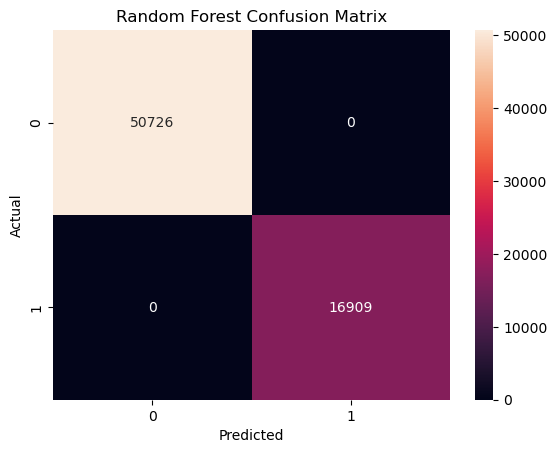

In [10]:

# Confusion Matrix
plt.figure()
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



## Feature Importance Analysis


In [11]:

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance


miss_distance             0.945465
relative_velocity         0.030832
estimated_diameter_max    0.012607
estimated_diameter_min    0.008203
absolute_magnitude        0.002893
dtype: float64

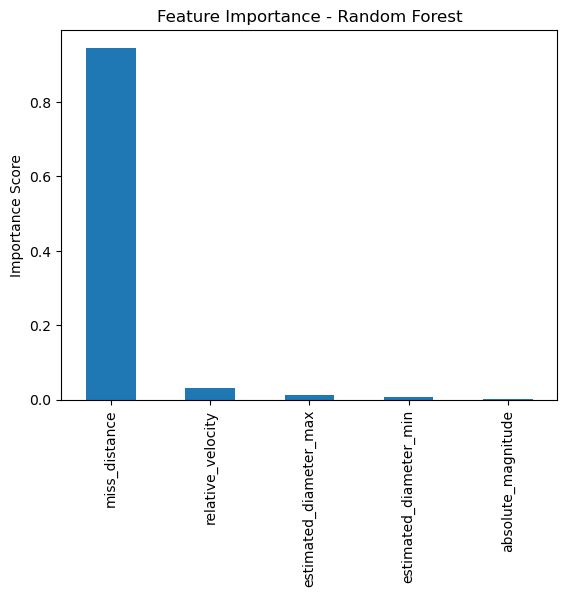

In [12]:

# Feature importance visualization
plt.figure()
feature_importance.plot(kind="bar")
plt.title("Feature Importance - Random Forest")
plt.ylabel("Importance Score")
plt.show()



## Conclusion

- Random Forest improves classification performance compared to Logistic Regression.
- Miss distance is the most influential feature in determining risk.
- Feature importance helps explain model decisions, making the model more interpretable.
- This model is suitable for real-world risk screening and can be further enhanced
  using XGBoost or hyperparameter tuning.
